In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


 Differences Between Different Classes of Gift
#### Our Answer: - There are three different classes of Gifts: Monetary, Contract, and Real Estate. Monetary is typically a one time payment from one party to another without any expectation of return. A contract is a legal agreement for an allocated time to give money between two parties. Real Estate is the giving of physical property of land and the resources that reside therein.

In [136]:
list(df['Gift Type'].unique())
# Total amount for each gift type
result=df.groupby('Gift Type')['Foreign Gift Amount'].sum().reset_index()
result.style.format({'Foreign Gift Amount': '{:,.0f}'})

,Gift Type,Foreign Gift Amount
0,Contract,"10,809,974,431"
1,Monetary Gift,"5,775,853,163"
2,Real Estate,"14,687,920"


Which Country Gives the most money?

Answer: 
Qatar gives the most amount of money with a total gift amount of 2,706,240,869.  


In [137]:
result = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest(1).reset_index()
result.style.format({'Foreign Gift Amount': '{:,.0f}'})

,Country of Giftor,Foreign Gift Amount
0,QATAR,"2,706,240,869"


Question 2: Which Country Initiates the Most Number of Gifts?

Answer:
England inititates the most number of gifts.

In [138]:
df['Country of Giftor'].value_counts().head(1).reset_index()

,Country of Giftor,count
0,ENGLAND,3655


Question 3: Which Country Has the highest Average Gift?

Answer: Bermuda has the highest average gift amount of 7,688,837

In [139]:
# Average gift amount by country
result=df.groupby('Country of Giftor')['Foreign Gift Amount'].mean().nlargest(1).round(0).reset_index()
result.style.format({'Foreign Gift Amount': '{:,.0f}'})

,Country of Giftor,Foreign Gift Amount
0,BERMUDA,"7,688,837"


Question 4: Which University Recieves the Most Amount of Gift?

Answer:
Carnegie Mellon University receives the most amount of gift.

In [145]:
result=df.groupby('Institution Name')['Foreign Gift Amount'].sum().nlargest(1).reset_index(name='Total Gift Amount')
result.style.format({'Total Gift Amount': '{:,.0f}'})

,Institution Name,Total Gift Amount
0,Carnegie Mellon University,"1,477,922,504"


Question 5: Which University Recieves the Highest Number of Gifts?

Answer:


UCLA recieves the highest number of gifts by count. 

In [141]:
import plotly.graph_objects as go

top_20_institutions = df['Institution Name'].value_counts().head(20).reset_index()
top_20_institutions.columns = ['Institution Name', 'Number of Gifts']

fig = go.Figure(data=[
    go.Bar(y=top_20_institutions['Institution Name'], 
           x=top_20_institutions['Number of Gifts'],
           orientation='h')
])
fig.update_layout(title='Top 20 Institutions by Number of Foreign Gifts Received',
                  xaxis_title='Number of Gifts',
                  yaxis_title='Institution Name',
                  height=800)
fig.show()





Question 6: Why Mean and Median Are Different?

Answer : The mean and median values are different because each university receives different gift amounts. Some gifts are small and some gifts are huge. As a result, mean gets pulled toward larger gifts or it is affected by the outliers. However, median stays in the middle and unaffected by the outliers. 


In [142]:
avg_per_university = df.groupby('Institution Name')['Foreign Gift Amount'].agg(['mean', 'median']).round(2).reset_index()
avg_per_university.style.format({'mean': '${:,.2f}', 'median': '${:,.2f}'})



,Institution Name,mean,median
0,Adelphi University,"$333,333.33","$250,000.00"
1,Albert Einstein College of Medicine,"$708,730.83","$668,340.50"
2,Alfred University,"$1,355,849.50","$1,355,849.50"
3,American University (The),"$872,250.00","$994,500.00"
4,Amherst College,"$389,361.50","$389,361.50"
5,Arizona State University,"$281,516.01","$66,280.00"
6,Auburn University Montgomery,"$70,991.90","$63,994.00"
7,Babson College,"$137,660.80","$100,000.00"
8,Ball State University,"$2,155,616.53","$1,706,800.00"
9,Barnard College,"$180,000.00","$125,000.00"


Total Market Mean and Median:
Each university on average brings in a total of $52.2 Million in gifts. 

In [35]:
average= df.groupby('Institution Name')['Foreign Gift Amount'].sum().describe().map('{:,.0f}'.format)
average

count              318
mean        52,202,879
std        153,571,597
min                500
25%          1,588,842
50%          6,486,792
75%         31,770,630
max      1,477,922,504
Name: Foreign Gift Amount, dtype: object

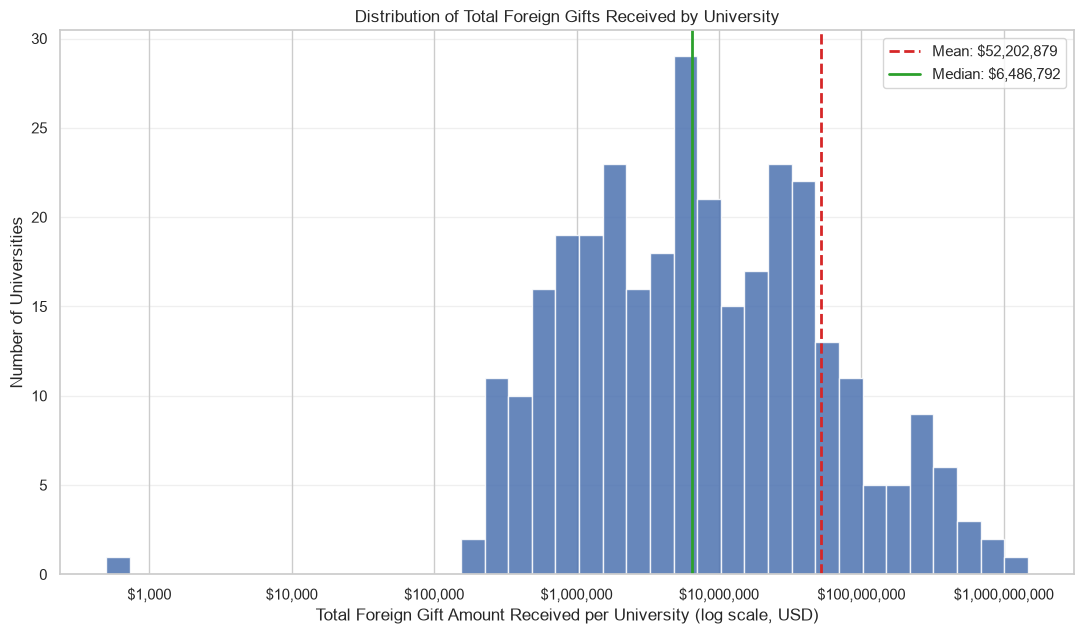

In [166]:
import matplotlib.ticker as mticker

by_univ = df.groupby('Institution Name')['Foreign Gift Amount'].sum()

mean_val = by_univ.mean()
median_val = by_univ.median()

# Plot
fig, ax = plt.subplots(figsize=(11, 6.5))

# log-spaced bins since totals span $500 to $1.5B
log_vals = np.log10(by_univ[by_univ > 0])
bins = np.logspace(log_vals.min(), log_vals.max(), 40)

ax.hist(by_univ, bins=bins, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.set_xscale("log")

ax.axvline(mean_val, color="#D62728", linestyle="--", linewidth=2,
           label=f"Mean: ${mean_val:,.0f}")
ax.axvline(median_val, color="#2CA02C", linestyle="-", linewidth=2,
           label=f"Median: ${median_val:,.0f}")

ax.set_xlabel("Total Foreign Gift Amount Received per University (log scale, USD)")
ax.set_ylabel("Number of Universities")
ax.set_title("Distribution of Total Foreign Gifts Received by University")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("university_gifts_histogram.png", dpi=150)
plt.show()


Question 7: The single largest flow of gift from a single country to a single institution is Qatar to Cornell University. 

In [170]:
flow=df.groupby(['Country of Giftor', 'Institution Name'])['Foreign Gift Amount'].sum().reset_index().sort_values(by='Foreign Gift Amount', ascending=False).head(5)
flow.style.format({'Foreign Gift Amount': '${:,.0f}'})

,Country of Giftor,Institution Name,Foreign Gift Amount
1865,QATAR,Cornell University,"$1,018,473,315"
159,BERMUDA,Carnegie Mellon University,"$750,000,000"
1884,QATAR,Texas A&M University,"$504,099,350"
1864,QATAR,Carnegie Mellon University,"$425,410,702"
1872,QATAR,Georgetown University,"$327,128,310"


In [181]:
import plotly.graph_objects as go

# giftor = 'Giftor Name'
# recipi = 'Institution Name'
# flor = 'Foreign Gift Amount'

giftor = 'Giftor Name'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()



Question 8: The top donors to US institutions are as Follows:

In [180]:
Top_giftors =df.groupby('Giftor Name')['Foreign Gift Amount'].sum().nlargest(5).sort_values(ascending=False).reset_index()
Top_giftors.style.format({'Foreign Gift Amount': '${:,.0f}'})

,Giftor Name,Foreign Gift Amount
0,Qatar Foundation,"$1,166,503,744"
1,Qatar Foundation/Qatar National Res,"$796,197,000"
2,Qatar Foundation for Education,"$373,945,215"
3,Anonymous,"$338,793,629"
4,Saudi Arabian Cultural Mission,"$275,221,475"
